In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
xcoord = np.linspace(-1,1,N)
ycoord = np.linspace(1,-1,N)
X, Y = np.meshgrid(xcoord,ycoord)
ε0 = 1

class Charge:
    def __init__(self,x,y,charge):
        self.x = x
        self.y = y
        self.charge = charge
    def X(self):
       return np.ones_like(X)*self.x
    def Y(self):
        return np.ones_like(X)*self.y

charges = [Charge(0,0,1),Charge(0.4,0.2,-1),Charge(0.5,0.2,4)]
distances = np.array([np.sqrt((X-c.X())**2 + (Y-c.Y())**2) for c in charges])
Efields = 1/(4*np.pi*ε0) * np.array([c.charge/d**2 for d,c in zip(distances,charges)])
Vfields = 1/(4*np.pi*ε0) * np.array([c.charge/d for d,c in zip(distances,charges)])
E = np.sum(Efields, axis=0)
V = np.sum(Vfields, axis=0)

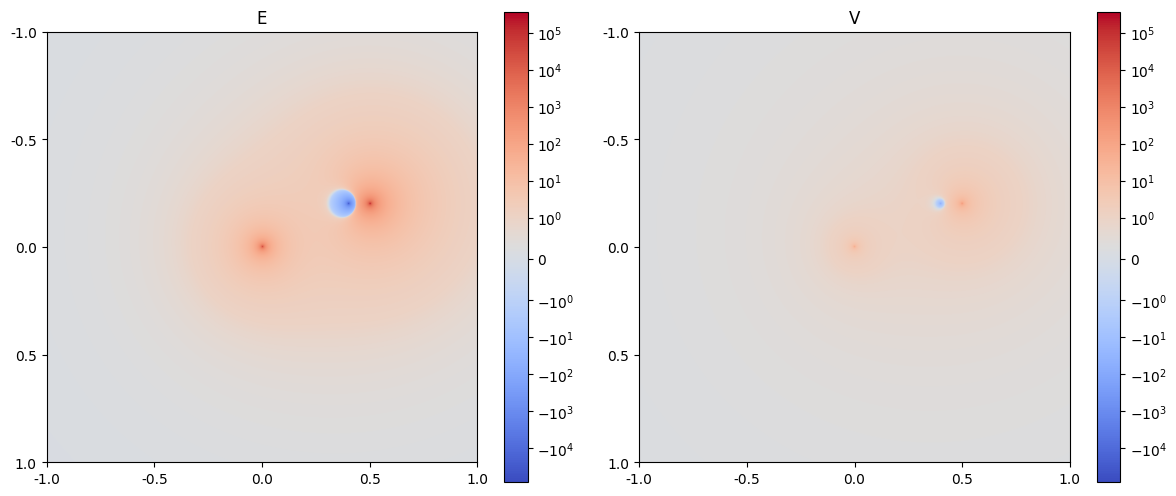

In [2]:
from matplotlib.colors import SymLogNorm

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT: imshow(E) ---
norm = SymLogNorm(
    linthresh=1,
    linscale=1,
    vmin=E.min(),
    vmax=E.max()
)

im = ax[0].imshow(E, cmap='coolwarm', norm=norm)
fig.colorbar(im, ax=ax[0])

ax[0].set_xticks(np.arange(0, N+N/4, N/4))
ax[0].set_xticklabels(np.arange(-1, 1.5, 0.5))
ax[0].set_yticks(np.arange(0, N+N/4, N/4))
ax[0].set_yticklabels(np.arange(-1, 1.5, 0.5))
ax[0].set_title("E")

# --- RIGHT: plot V ---
im = ax[1].imshow(V, cmap='coolwarm', norm=norm)
fig.colorbar(im, ax=ax[1])
ax[1].set_xticks(np.arange(0, N+N/4, N/4))
ax[1].set_xticklabels(np.arange(-1, 1.5, 0.5))
ax[1].set_yticks(np.arange(0, N+N/4, N/4))
ax[1].set_yticklabels(np.arange(-1, 1.5, 0.5))
ax[1].set_title("V")

plt.tight_layout()
plt.show()

In [74]:
N = 40
xcoord = np.linspace(-1,1,N)
ycoord = np.linspace(1,-1,N)
X, Y = np.meshgrid(xcoord,ycoord)
ε0 = 1

charges = [Charge(0.3,0.3,1),Charge(-0.3,-0.3,-1)] # ,Charge(0.5,-0.2,-1)] # ,Charge(0.4,0.2,-1),Charge(0.5,0.2,4)]
distances = np.array([np.sqrt((X-c.X())**2 + (Y-c.Y())**2) for c in charges])
Efields = 1/(4*np.pi*ε0) * np.array([c.charge/d**2 for d,c in zip(distances,charges)])
Vfields = 1/(4*np.pi*ε0) * np.array([c.charge/d for d,c in zip(distances,charges)])
E = np.sum(Efields, axis=0) # mag
V = np.sum(Vfields, axis=0) # mag
u = np.sum([np.sign(c.charge) * (X-c.X())/d for d,c in zip(distances,charges)],axis=0) # versori da normalizzare
v = np.sum([np.sign(c.charge) * (Y-c.Y())/d for d,c in zip(distances,charges)],axis=0) # versori da normalizzare
norm = np.sqrt(u**2+v**2)
u = u/norm # versore
v = v/norm # versore

C:\Users\jocar\AppData\Local\Temp\ipykernel_8620\2148267870.py:16: RuntimeWarning: invalid value encountered in divide
  u = u/norm # versore
C:\Users\jocar\AppData\Local\Temp\ipykernel_8620\2148267870.py:17: RuntimeWarning: invalid value encountered in divide
  v = v/norm # versore


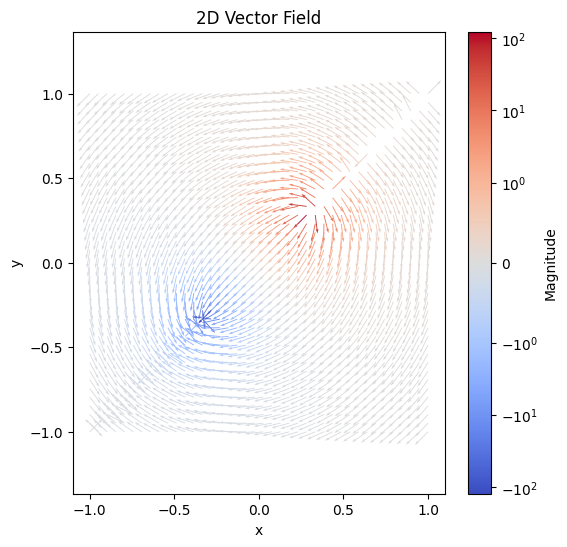

In [75]:
norm = SymLogNorm(linthresh=1, linscale=1, vmin=E.min(), vmax=E.max())
plt.figure(figsize=(6,6))

q = plt.quiver(
    X, Y, u, v,
    E,               # this controls arrow colors
    cmap='coolwarm',
    norm=norm,
    scale=20       # adjust arrow size
)


plt.colorbar(q, label="Magnitude")
plt.title("2D Vector Field")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

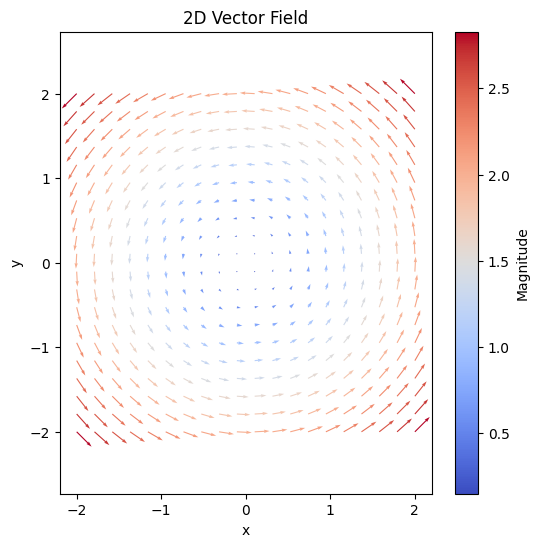

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

# Create grid
x, y = np.meshgrid(
    np.linspace(-2, 2, 20),
    np.linspace(-2, 2, 20)
)

# Example vector field
u = -y
v = x

# Magnitude (for coloring)
mag = np.sqrt(u**2 + v**2)

# Normalize for colormap
norm = Normalize(vmin=mag.min(), vmax=mag.max())

# Plot
plt.figure(figsize=(6,6))

q = plt.quiver(
    x, y, u, v,
    mag,               # this controls arrow colors
    cmap='coolwarm',
    norm=norm,
    scale=50           # adjust arrow size
)

plt.colorbar(q, label="Magnitude")
plt.title("2D Vector Field")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()


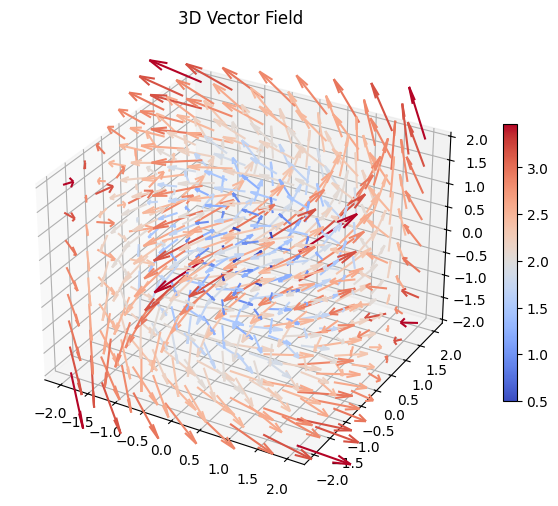

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize

# Create grid
x, y, z = np.meshgrid(
    np.linspace(-2, 2, 8),
    np.linspace(-2, 2, 8),
    np.linspace(-2, 2, 8)
)

# Example vector field
u = -y
v = x
w = z

# Magnitude for coloring
mag = np.sqrt(u**2 + v**2 + w**2)

# Normalize colors
norm = Normalize(vmin=mag.min(), vmax=mag.max())
colors = cm.coolwarm(norm(mag))

# Flatten everything (required for quiver coloring)
x, y, z = x.flatten(), y.flatten(), z.flatten()
u, v, w = u.flatten(), v.flatten(), w.flatten()
colors = colors.reshape(-1, 4)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

q = ax.quiver(x, y, z, u, v, w, 
              colors=colors,
              length=0.3,
              normalize=False)

# Add colorbar
mappable = cm.ScalarMappable(norm=norm, cmap='coolwarm')
mappable.set_array([])
fig.colorbar(mappable, ax=ax, shrink=0.6)

ax.set_title("3D Vector Field")
plt.show()
